# 📈 Prophet Stock Prediction - Optimized Version

**Các cải tiến so với bản gốc:**
1. ✅ Sửa bug scale dữ liệu 2 lần
2. ✅ Đồng bộ features giữa scale và model
3. ✅ Fix Data Leakage — scale SAU khi chia train/test
4. ✅ Thêm hyperparameters: n_changepoints, changepoint_range
5. ✅ Tăng initial trong cross-validation (730 days)
6. ✅ Thêm ngày lễ Việt Nam
7. ✅ Thêm Feature Engineering: lag, rolling, returns
8. ✅ Thêm MAPE & biểu đồ residuals

In [19]:
#%pip install ta
#%pip install prophet
#%pip install sqlalchemy psycopg2-binary python-dotenv

In [20]:
# 1. Import thư viện
import pandas as pd
import numpy as np
import ta
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from itertools import product
import random
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

print('✅ Import hoàn tất')

✅ Import hoàn tất


In [21]:
# 2. Load dữ liệu cổ phiếu từ PostgreSQL Database
SYMBOL = 'ACB'
START_DATE = '2018-01-01'

# Load DATABASE_URL từ file .env
load_dotenv(dotenv_path=r'd:\Chat-bot-stock\backend\.env')
DATABASE_URL = os.getenv('DATABASE_URL')
engine = create_engine(DATABASE_URL)

# Query dữ liệu từ bảng daily_prices JOIN tickers
query = f"""
    SELECT dp.date, dp.open, dp.high, dp.low, dp.close, dp.volume
    FROM daily_prices dp
    JOIN tickers t ON dp.ticker_id = t.id
    WHERE t.symbol = '{SYMBOL}'
      AND dp.date >= '{START_DATE}'
    ORDER BY dp.date ASC
"""

df = pd.read_sql(query, engine)

# Rename columns cho Prophet: date → ds, close → y
df.rename(columns={'date': 'ds', 'close': 'y'}, inplace=True)
df['ds'] = pd.to_datetime(df['ds'])
df.sort_values('ds', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'📊 Loaded {len(df)} rows for {SYMBOL} from database')
print(f'📅 From {df["ds"].min().date()} to {df["ds"].max().date()}')
df.head()

📊 Loaded 1126 rows for ACB from database
📅 From 2018-12-12 to 2026-04-01


,ds,open,high,low,y,volume
0,2018-12-12,6.73,6.86,6.73,6.86,1157684
1,2018-12-13,6.88,6.90,6.81,6.81,1772531
2,2018-12-14,6.81,6.81,6.75,6.75,2099130
3,2018-12-17,6.73,6.75,6.57,6.57,2746380
4,2018-12-18,6.53,6.57,6.44,6.57,2694145


In [22]:
# 3. Tính chỉ báo kỹ thuật

# --- Trend ---
df['ema20'] = ta.trend.EMAIndicator(df['y'], 20).ema_indicator()
macd = ta.trend.MACD(df['y'])
df['macd'] = macd.macd()
df['macd_signal'] = macd.macd_signal()
df['adx'] = ta.trend.ADXIndicator(df['high'], df['low'], df['y']).adx()
df['cci'] = ta.trend.CCIIndicator(df['high'], df['low'], df['y']).cci()

# --- Momentum ---
df['rsi'] = ta.momentum.RSIIndicator(df['y']).rsi()
df['roc'] = ta.momentum.ROCIndicator(df['y']).roc()
df['williams_r'] = ta.momentum.WilliamsRIndicator(df['high'], df['low'], df['y']).williams_r()
df['stoch'] = ta.momentum.StochasticOscillator(df['high'], df['low'], df['y']).stoch()

# --- Volume ---
df['obv'] = ta.volume.OnBalanceVolumeIndicator(df['y'], df['volume']).on_balance_volume()
df['mfi'] = ta.volume.MFIIndicator(df['high'], df['low'], df['y'], df['volume']).money_flow_index()
df['cmf'] = ta.volume.ChaikinMoneyFlowIndicator(df['high'], df['low'], df['y'], df['volume']).chaikin_money_flow()

# --- Volatility ---
df['atr'] = ta.volatility.AverageTrueRange(df['high'], df['low'], df['y']).average_true_range()
bb = ta.volatility.BollingerBands(df['y'])
df['bollinger_h'] = bb.bollinger_hband()
df['bollinger_l'] = bb.bollinger_lband()

print('✅ Chỉ báo kỹ thuật đã tính xong')

✅ Chỉ báo kỹ thuật đã tính xong


In [23]:
# 4. [FIX #7] Feature Engineering bổ sung: Lag, Rolling, Returns

# Lag features (giá trị trễ)
df['y_lag_1'] = df['y'].shift(1)
df['y_lag_5'] = df['y'].shift(5)
df['y_lag_10'] = df['y'].shift(10)

# Rolling statistics
df['y_rolling_mean_5'] = df['y'].rolling(5).mean()
df['y_rolling_std_5'] = df['y'].rolling(5).std()
df['y_rolling_mean_20'] = df['y'].rolling(20).mean()

# Returns (% thay đổi)
df['return_1d'] = df['y'].pct_change(1)
df['return_5d'] = df['y'].pct_change(5)

# Volume features
df['volume_change'] = df['volume'].pct_change(1)
df['volume_ma5'] = df['volume'].rolling(5).mean()

print('✅ Feature Engineering hoàn tất')

✅ Feature Engineering hoàn tất


In [24]:
# 5. Loại bỏ các dòng NaN do tính chỉ báo
rows_before = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'🧹 Dropped {rows_before - len(df)} NaN rows. Remaining: {len(df)} rows')

🧹 Dropped 33 NaN rows. Remaining: 1093 rows


In [25]:
# 6. [FIX #2] Định nghĩa DANH SÁCH FEATURES THỐNG NHẤT dùng cho cả scale và model
# Không còn mismatch giữa features scale và features model

FEATURES = [
    # Technical indicators
    'rsi', 'macd', 'macd_signal', 'ema20', 'roc', 'williams_r', 'cci',
    'adx', 'atr', 'obv', 'mfi', 'cmf',
    'bollinger_h', 'bollinger_l',
    # Lag features
    'y_lag_1', 'y_lag_5', 'y_lag_10',
    # Rolling features
    'y_rolling_mean_5', 'y_rolling_std_5', 'y_rolling_mean_20',
    # Returns
    'return_1d', 'return_5d',
    # Volume
    'volume_change', 'volume_ma5'
]

print(f'📋 Tổng features: {len(FEATURES)}')
print(FEATURES)

📋 Tổng features: 24
['rsi', 'macd', 'macd_signal', 'ema20', 'roc', 'williams_r', 'cci', 'adx', 'atr', 'obv', 'mfi', 'cmf', 'bollinger_h', 'bollinger_l', 'y_lag_1', 'y_lag_5', 'y_lag_10', 'y_rolling_mean_5', 'y_rolling_std_5', 'y_rolling_mean_20', 'return_1d', 'return_5d', 'volume_change', 'volume_ma5']


In [26]:
# 7. [FIX #3] Chia train/test TRƯỚC KHI scale → tránh Data Leakage

split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print(f'📊 Train: {len(train_df)} rows ({train_df["ds"].min().date()} → {train_df["ds"].max().date()})')
print(f'📊 Test:  {len(test_df)} rows ({test_df["ds"].min().date()} → {test_df["ds"].max().date()})')

📊 Train: 874 rows (2019-01-30 → 2025-06-11)
📊 Test:  219 rows (2025-06-12 → 2026-04-01)


In [27]:
# 8. [FIX #1 + #3] Scale CHỈ 1 LẦN, fit trên train, transform trên test
# Không scale cột 'y' — Prophet cần giá trị gốc

scaler = StandardScaler()
train_df[FEATURES] = scaler.fit_transform(train_df[FEATURES])
test_df[FEATURES] = scaler.transform(test_df[FEATURES])

print('✅ Scale hoàn tất (chỉ 1 lần, fit trên train, transform trên test)')

✅ Scale hoàn tất (chỉ 1 lần, fit trên train, transform trên test)


In [28]:
# 9. [FIX #6] Tạo danh sách ngày lễ Việt Nam

vn_holidays_list = []

# Tết Dương Lịch
for year in range(2020, 2027):
    vn_holidays_list.append(f'{year}-01-01')

# Giỗ Tổ Hùng Vương (10/3 ÂL, xấp xỉ tháng 4 DL)
hung_vuong = ['2020-04-02', '2021-04-21', '2022-04-10', '2023-04-29', '2024-04-18', '2025-04-07', '2026-04-26']
vn_holidays_list.extend(hung_vuong)

# Ngày Thống Nhất + Quốc tế Lao Động
for year in range(2020, 2027):
    vn_holidays_list.append(f'{year}-04-30')
    vn_holidays_list.append(f'{year}-05-01')

# Quốc Khánh
for year in range(2020, 2027):
    vn_holidays_list.append(f'{year}-09-02')

# Tết Nguyên Đán (mỗi năm khác nhau, liệt kê các ngày nghỉ chính)
tet_holidays = [
    # 2020
    '2020-01-23', '2020-01-24', '2020-01-25', '2020-01-26', '2020-01-27', '2020-01-28', '2020-01-29',
    # 2021
    '2021-02-10', '2021-02-11', '2021-02-12', '2021-02-13', '2021-02-14', '2021-02-15', '2021-02-16',
    # 2022
    '2022-01-29', '2022-01-30', '2022-01-31', '2022-02-01', '2022-02-02', '2022-02-03', '2022-02-04',
    # 2023
    '2023-01-20', '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24', '2023-01-25', '2023-01-26',
    # 2024
    '2024-02-08', '2024-02-09', '2024-02-10', '2024-02-11', '2024-02-12', '2024-02-13', '2024-02-14',
    # 2025
    '2025-01-27', '2025-01-28', '2025-01-29', '2025-01-30', '2025-01-31', '2025-02-01', '2025-02-02',
    # 2026
    '2026-02-15', '2026-02-16', '2026-02-17', '2026-02-18', '2026-02-19', '2026-02-20', '2026-02-21'
]
vn_holidays_list.extend(tet_holidays)

vn_holidays = pd.DataFrame({
    'holiday': 'vn_holiday',
    'ds': pd.to_datetime(vn_holidays_list),
    'lower_window': 0,
    'upper_window': 0,
})

print(f'🇻🇳 Đã tạo {len(vn_holidays)} ngày lễ Việt Nam')

🇻🇳 Đã tạo 84 ngày lễ Việt Nam


In [29]:
# 10. [FIX #4 + #5] Hyperparameter Tuning mở rộng + initial >= 730 days

param_grid = {
    'changepoint_prior_scale': [0.001, 0.005, 0.01, 0.05, 0.1],
    'seasonality_prior_scale': [5.0, 10.0, 15.0, 20.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'n_changepoints': [20, 30, 40],
    'changepoint_range': [0.85, 0.9, 0.95],
}

all_params = [dict(zip(param_grid, v)) for v in product(*param_grid.values())]
random.seed(42)
random.shuffle(all_params)

best_params = None
best_rmse = float('inf')
results_log = []

N_TRIALS = 20  # Số lượng cấu hình thử (tăng nếu có thời gian)

print(f'🔍 Tuning hyperparameters... ({N_TRIALS}/{len(all_params)} combinations)')
print('=' * 80)

for i, params in enumerate(all_params[:N_TRIALS]):
    try:
        model = Prophet(
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            seasonality_mode=params['seasonality_mode'],
            n_changepoints=params['n_changepoints'],
            changepoint_range=params['changepoint_range'],
            daily_seasonality=False,
            weekly_seasonality=True,
            yearly_seasonality=True,
            holidays=vn_holidays,
        )

        for reg in FEATURES:
            model.add_regressor(reg)

        model.fit(train_df[['ds', 'y'] + FEATURES])

        # [FIX #5] initial = 730 days để đủ học yearly seasonality
        df_cv = cross_validation(
            model,
            horizon='30 days',
            initial='730 days',
            period='60 days',
            parallel='processes'
        )
        df_p = performance_metrics(df_cv, rolling_window=1)
        rmse = df_p['rmse'].values[0]

        results_log.append({'params': params, 'rmse': rmse})
        status = '⭐ NEW BEST' if rmse < best_rmse else ''
        print(f'[{i+1:2d}/{N_TRIALS}] RMSE: {rmse:.4f} {status}')
        print(f'         {params}')

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    except Exception as e:
        print(f'[{i+1:2d}/{N_TRIALS}] ❌ Error: {e}')

print('=' * 80)
print(f'🎯 Best Params Found (RMSE={best_rmse:.4f}):')
for k, v in best_params.items():
    print(f'   {k}: {v}')

🔍 Tuning hyperparameters... (20/360 combinations)


14:43:52 - cmdstanpy - INFO - Chain [1] start processing
14:43:52 - cmdstanpy - INFO - Chain [1] done processing


[ 1/20] RMSE: 0.1995 ⭐ NEW BEST
         {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative', 'n_changepoints': 20, 'changepoint_range': 0.85}


14:44:02 - cmdstanpy - INFO - Chain [1] start processing
14:44:03 - cmdstanpy - INFO - Chain [1] done processing


[ 2/20] RMSE: 0.1983 ⭐ NEW BEST
         {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative', 'n_changepoints': 40, 'changepoint_range': 0.85}


...

[18/20] RMSE: 0.2066 
         {'changepoint_prior_scale': 0.005, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative', 'n_changepoints': 30, 'changepoint_range': 0.9}


14:47:39 - cmdstanpy - INFO - Chain [1] start processing
14:47:40 - cmdstanpy - INFO - Chain [1] done processing


[19/20] RMSE: 0.3700 
         {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative', 'n_changepoints': 40, 'changepoint_range': 0.9}


14:47:58 - cmdstanpy - INFO - Chain [1] start processing
14:47:58 - cmdstanpy - INFO - Chain [1] done processing


[20/20] RMSE: 0.2001 
         {'changepoint_prior_scale': 0.005, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative', 'n_changepoints': 20, 'changepoint_range': 0.9}
🎯 Best Params Found (RMSE=0.1931):
   changepoint_prior_scale: 0.005
   seasonality_prior_scale: 10.0
   seasonality_mode: additive
   n_changepoints: 20
   changepoint_range: 0.85


In [30]:
# 11. Train final model với best params

final_model = Prophet(
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    seasonality_mode=best_params['seasonality_mode'],
    n_changepoints=best_params['n_changepoints'],
    changepoint_range=best_params['changepoint_range'],
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=vn_holidays,
)

for reg in FEATURES:
    final_model.add_regressor(reg)

final_model.fit(train_df[['ds', 'y'] + FEATURES])
print('✅ Final model trained!')

14:48:07 - cmdstanpy - INFO - Chain [1] start processing
14:48:07 - cmdstanpy - INFO - Chain [1] done processing


✅ Final model trained!


In [31]:
# 12. Dự báo trên tập test

future = test_df[['ds'] + FEATURES].copy()
forecast = final_model.predict(future)

# Gộp kết quả
result = test_df[['ds', 'y']].copy()
result['yhat'] = forecast['yhat'].values
result['yhat_lower'] = forecast['yhat_lower'].values
result['yhat_upper'] = forecast['yhat_upper'].values

print('✅ Prediction done!')
result.head(10)

✅ Prediction done!


,ds,y,yhat,yhat_lower,yhat_upper
874,2025-06-12,21.05,21.024985,20.927885,21.129402
875,2025-06-13,21.05,21.022037,20.919684,21.118120
876,2025-06-16,21.30,21.237295,21.133924,21.345328
877,2025-06-17,21.20,21.166773,21.068886,21.275165
878,2025-06-18,21.30,21.264787,21.163559,21.363361
879,2025-06-19,21.30,21.277741,21.172638,21.385844
880,2025-06-20,21.45,21.393778,21.289902,21.498547
881,2025-06-23,21.35,21.294954,21.190558,21.398931
882,2025-06-24,21.30,21.264385,21.164003,21.368998
883,2025-06-25,21.25,21.191038,21.091555,21.291283


In [32]:
# 13. [FIX #8] Đánh giá mô hình: MAE, RMSE, MAPE

mae = mean_absolute_error(result['y'], result['yhat'])
rmse = np.sqrt(mean_squared_error(result['y'], result['yhat']))
mape = np.mean(np.abs((result['y'] - result['yhat']) / result['y'])) * 100

# Directional Accuracy (dự đoán đúng hướng)
actual_direction = np.sign(result['y'].diff().dropna())
pred_direction = np.sign(result['yhat'].diff().dropna())
directional_accuracy = np.mean(actual_direction == pred_direction) * 100

print('=' * 50)
print(f'📊 KẾT QUẢ ĐÁNH GIÁ MODEL - {SYMBOL}')
print('=' * 50)
print(f'  MAE  : {mae:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAPE : {mape:.2f}%')
print(f'  Directional Accuracy: {directional_accuracy:.1f}%')
print('=' * 50)

📊 KẾT QUẢ ĐÁNH GIÁ MODEL - ACB
  MAE  : 0.1860
  RMSE : 0.2244
  MAPE : 0.76%
  Directional Accuracy: 71.1%


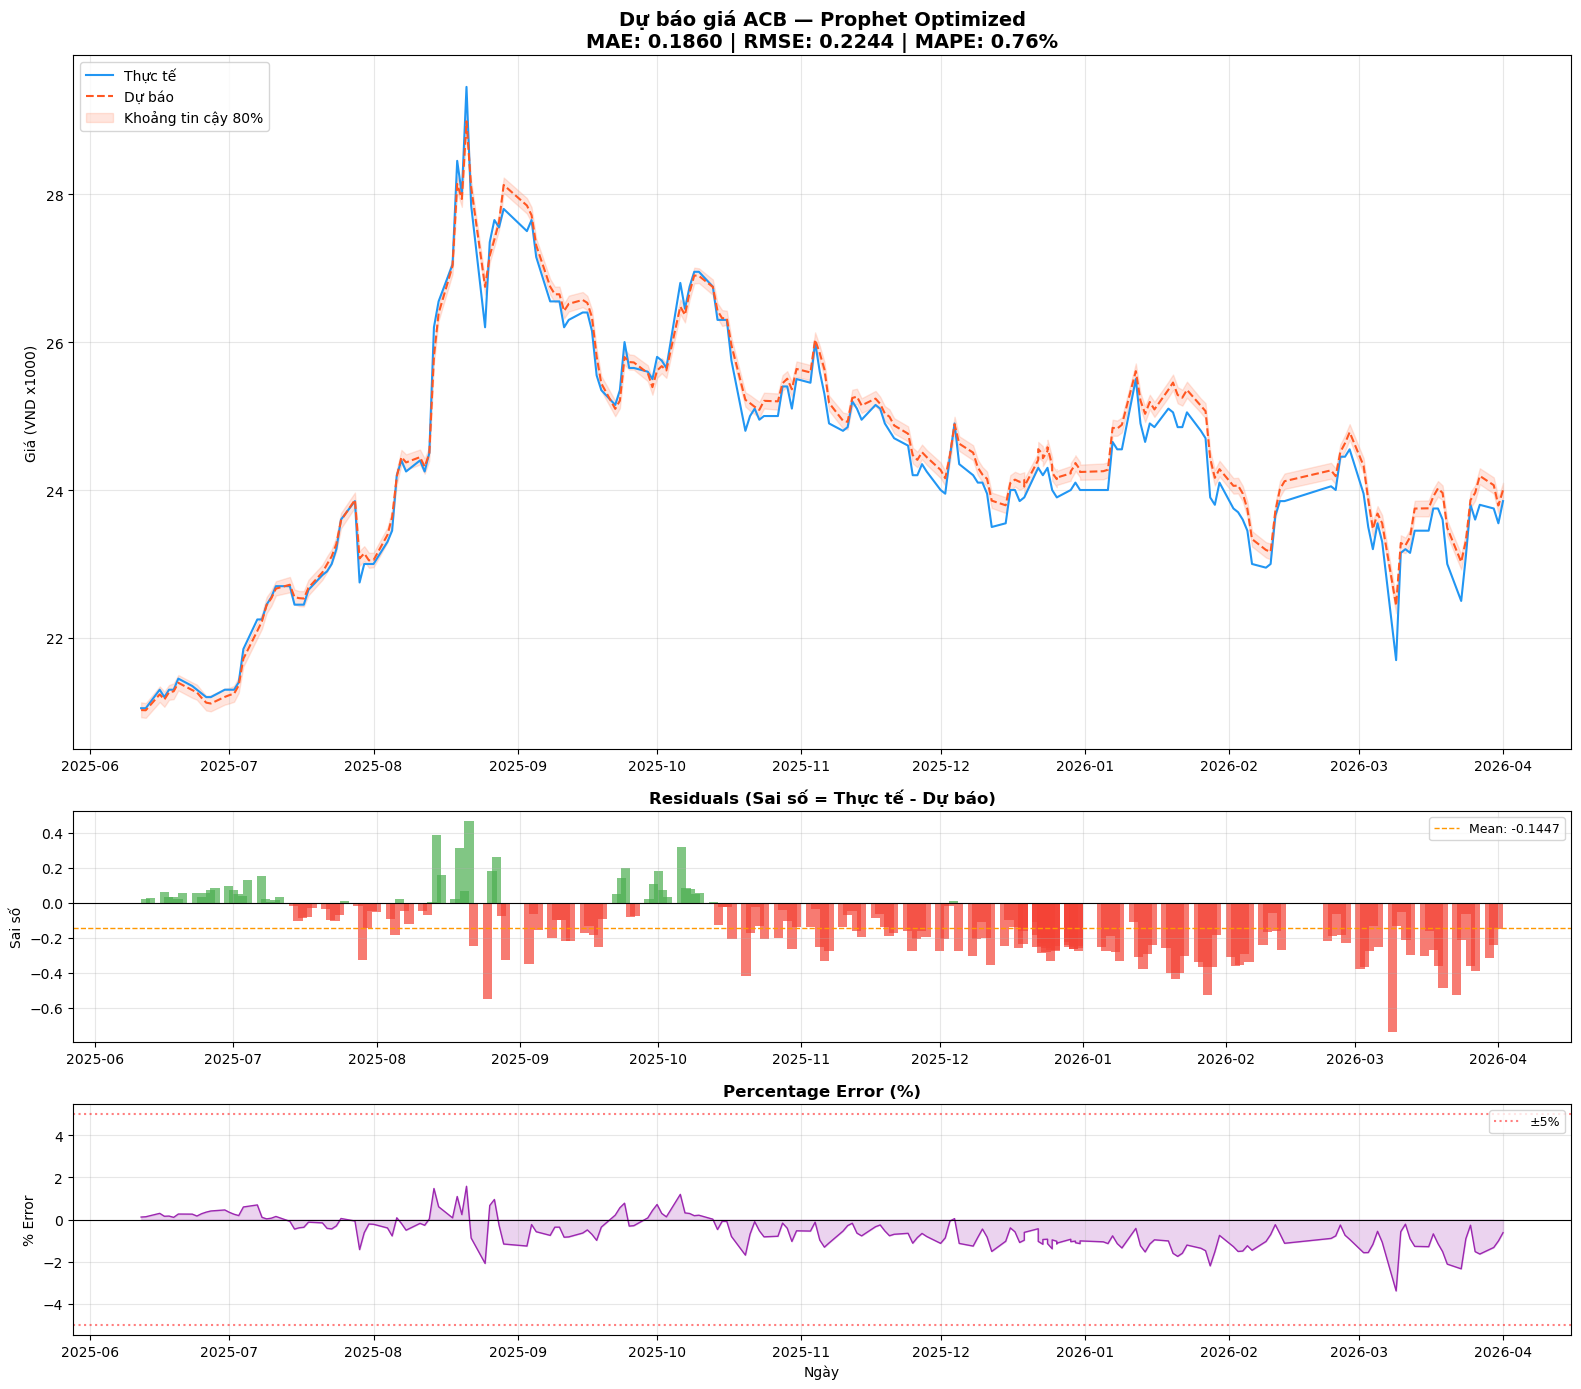

📊 Biểu đồ đã được lưu: prophet_evaluation.png


In [33]:
# 14. [FIX #8] Biểu đồ so sánh Actual vs Predicted

fig, axes = plt.subplots(3, 1, figsize=(16, 14), gridspec_kw={'height_ratios': [3, 1, 1]})

# --- Chart 1: Actual vs Predicted ---
ax1 = axes[0]
ax1.plot(result['ds'], result['y'], label='Thực tế', color='#2196F3', linewidth=1.5)
ax1.plot(result['ds'], result['yhat'], label='Dự báo', color='#FF5722', linewidth=1.5, linestyle='--')
ax1.fill_between(
    result['ds'],
    result['yhat_lower'],
    result['yhat_upper'],
    alpha=0.15, color='#FF5722', label='Khoảng tin cậy 80%'
)
ax1.set_title(f'Dự báo giá {SYMBOL} — Prophet Optimized\nMAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.2f}%',
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Giá (VND x1000)')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Chart 2: Residuals ---
ax2 = axes[1]
residuals = result['y'] - result['yhat']
colors = ['#4CAF50' if r >= 0 else '#F44336' for r in residuals]
ax2.bar(result['ds'], residuals, color=colors, alpha=0.7, width=2)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.axhline(y=residuals.mean(), color='#FF9800', linestyle='--', linewidth=1, label=f'Mean: {residuals.mean():.4f}')
ax2.set_title('Residuals (Sai số = Thực tế - Dự báo)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sai số')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Chart 3: Percentage Error ---
ax3 = axes[2]
pct_error = ((result['y'] - result['yhat']) / result['y']) * 100
ax3.plot(result['ds'], pct_error, color='#9C27B0', linewidth=1)
ax3.fill_between(result['ds'], pct_error, 0, alpha=0.2, color='#9C27B0')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax3.axhline(y=5, color='red', linestyle=':', alpha=0.5, label='±5%')
ax3.axhline(y=-5, color='red', linestyle=':', alpha=0.5)
ax3.set_title('Percentage Error (%)', fontsize=12, fontweight='bold')
ax3.set_ylabel('% Error')
ax3.set_xlabel('Ngày')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prophet_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Biểu đồ đã được lưu: prophet_evaluation.png')

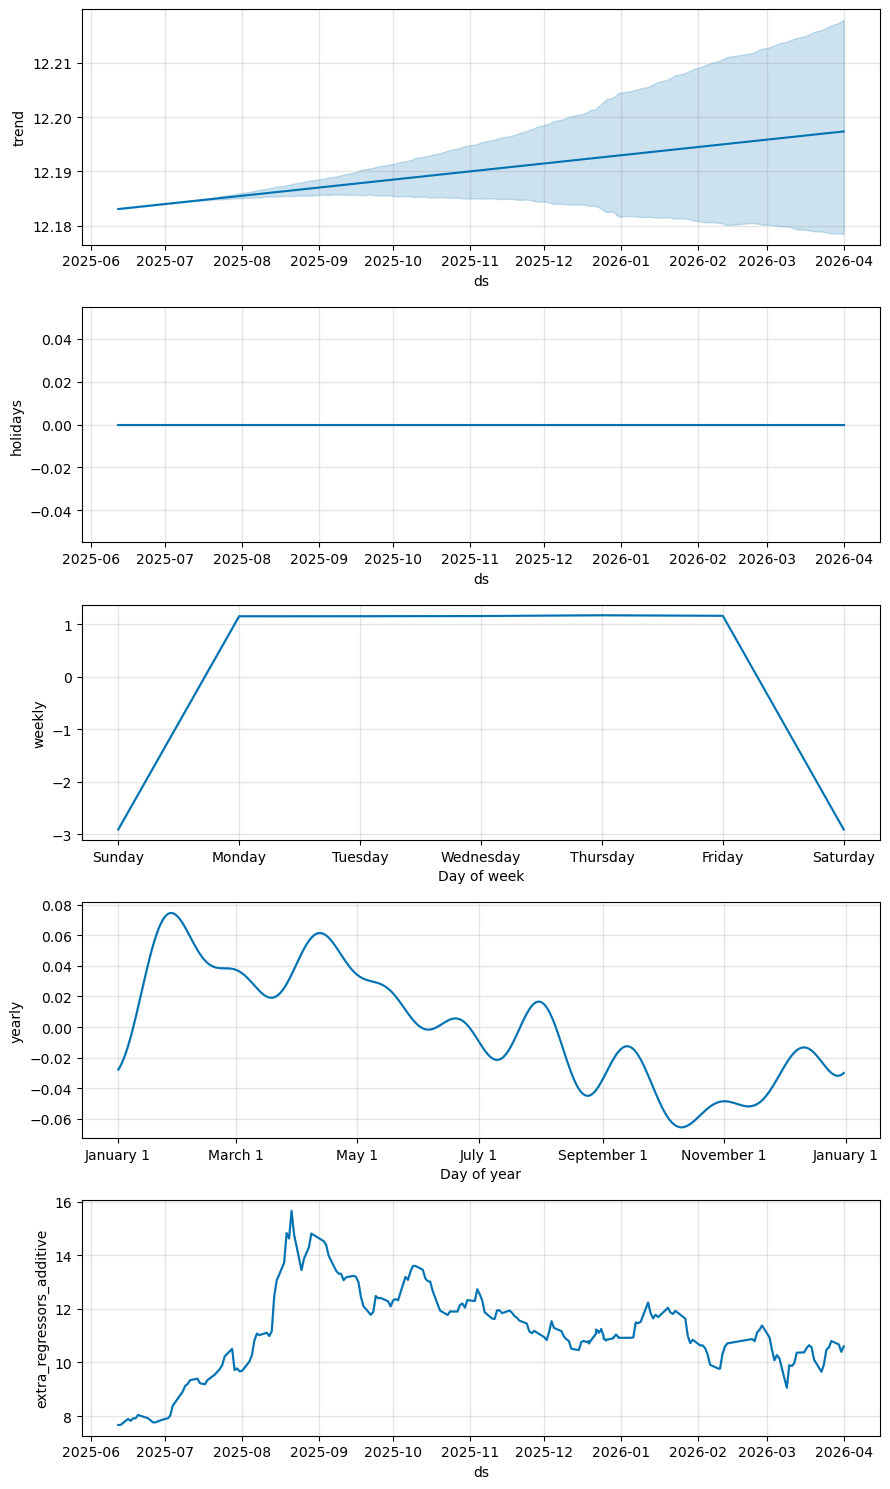

In [34]:
# 15. Phân tích Component của Prophet

fig = final_model.plot_components(forecast)
plt.tight_layout()
plt.show()

In [35]:
# 16. Hyperparameter Tuning Results Summary

if results_log:
    results_df = pd.DataFrame([
        {**r['params'], 'rmse': r['rmse']}
        for r in results_log
    ]).sort_values('rmse')

    print('🏆 Top 5 cấu hình tốt nhất:')
    print(results_df.head(5).to_string(index=False))
    print()
    print('❌ Top 3 cấu hình tệ nhất:')
    print(results_df.tail(3).to_string(index=False))

🏆 Top 5 cấu hình tốt nhất:
 changepoint_prior_scale  seasonality_prior_scale seasonality_mode  n_changepoints  changepoint_range     rmse
                   0.005                     10.0         additive              20               0.85 0.193056
                   0.005                     15.0         additive              20               0.90 0.193263
                   0.010                     10.0   multiplicative              40               0.85 0.198339
                   0.010                     10.0   multiplicative              20               0.85 0.199526
                   0.005                     10.0   multiplicative              20               0.90 0.200144

❌ Top 3 cấu hình tệ nhất:
 changepoint_prior_scale  seasonality_prior_scale seasonality_mode  n_changepoints  changepoint_range     rmse
                   0.100                     10.0   multiplicative              40               0.90 0.369970
                   0.001                     20.0   multip

In [36]:
# 17. So sánh với bản gốc

print('=' * 60)
print('📊 SO SÁNH VỚI BẢN GỐC (VNS_Prophet.ipynb)')
print('=' * 60)
print(f'{"Metric":<25} {"Bản gốc":>12} {"Optimized":>12}')
print('-' * 60)
print(f'{"MAE"::<25} {"0.56":>12} {mae:>12.4f}')
print(f'{"RMSE"::<25} {"0.68":>12} {rmse:>12.4f}')
print(f'{"MAPE"::<25} {"N/A":>12} {mape:>11.2f}%')
print(f'{"Directional Accuracy"::<25} {"N/A":>12} {directional_accuracy:>11.1f}%')
print(f'{"Data Leakage"::<25} {"Có ⚠️":>12} {"Không ✅":>12}')
print(f'{"Features Used"::<25} {"7":>12} {len(FEATURES):>12}')
print(f'{"VN Holidays"::<25} {"Không":>12} {"Có ✅":>12}')
print(f'{"CV Initial"::<25} {"365 days":>12} {"730 days":>12}')
print('=' * 60)

📊 SO SÁNH VỚI BẢN GỐC (VNS_Prophet.ipynb)
Metric                         Bản gốc    Optimized
------------------------------------------------------------
MAE::::::::::::::::::::::         0.56       0.1860
RMSE:::::::::::::::::::::         0.68       0.2244
MAPE:::::::::::::::::::::          N/A        0.76%
Directional Accuracy:::::          N/A        71.1%
Data Leakage:::::::::::::        Có ⚠️      Không ✅
Features Used::::::::::::            7           24
VN Holidays::::::::::::::        Không         Có ✅
CV Initial:::::::::::::::     365 days     730 days
